In [2]:
from IPython.display import display, HTML

display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:13pt;}
div.prompt {min-width:80px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:2px;}
table.dataframe{font-size:2xpt;}
div.text_cell_render h1 {
    color: #001A99 !important;
    font-weight: bold;
}
div.text_cell_render hr {
    border: 0 !important;
    height: 2px !important;
    background-color: #4FC3F7 !important;
}
</style>
"""))

# 1절. 변수 선택과 차원축소
## 1-1 변수선택과 차원축소
- 종속변수에영향을주는변수들을찾아학습에사용할독립변수의수를줄임(어떻게하면score를 높일수있을지?)
- 과적합과변수들사이의다중공선성(변수들간강한상관관계)을줄일수있음
* 회귀계수 해석이어려워짐. 모델예측력이좋아도해석력이떨어짐(어떤변수가제일큰요인인지잘), p값이나유의성검정이왜곡될수있음- 모형의학습시간을줄일수있음
- 주성분분석, 상관분석, **분류모형의 feature_importance_, 예측 모형의 coef_**
- SelectKBest : 가장 높은 score에 따라 K개의 특징을 선택
## 1-2 주성분분석(PCA, Principal Component Anaysis)
- 주성분분석은변수선택및차원축소방법(기존의모든변수를조합하여새로운변수로만듦) 으로널리사용
- 주성분분석은상관관계가있는변수들을선형결합해서**분산이극대화된상관관계가없는새로운변수(주성분)들로축약**하는것
- 주성분분석은사실선형대수학이라기보다는선형대수학의활용적인측면이강하며영상인식, 통계데이터분석(주성분 찾기), 데이터 압축, 노이즈제거 등여러분야에사용
- 영상처리에서많이활용: 여러개의영상중대표이미지를찾을때활용

In [1]:
import seaborn as sns
from sklearn.decomposition import PCA
iris = sns.load_dataset('iris')
iris_X, iris_y = iris.iloc[:, :-1], iris.iloc[:, -1]
iris_X.shape, iris_y.shape

((150, 4), (150,))

In [3]:
# 다중공전성이 있는 독립변수 4개를 다중공전성전혀 없는 새로운 독립변수 2개로
pca = PCA(n_components=2) # n_components : 주성분 갯수
pca.fit(iris_X)
iris_pca = pca.transform(iris_X)
iris_pca[:3] # 주성분 2개

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943]])

In [4]:
import pandas as pd
df = pd.DataFrame(iris_pca, columns=['pca1', 'pca2'])
df.corr()

,pca1,pca2
pca1,1.000000e+00,1.407550e-15
pca2,1.407550e-15,1.000000e+00


In [5]:
# iris_X => df
pd.concat([iris_X, df], axis=1)

,sepal_length,sepal_width,petal_length,petal_width,pca1,pca2
0,5.1,3.5,1.4,0.2,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,-2.728717,0.326755
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,1.944110,0.187532
146,6.3,2.5,5.0,1.9,1.527167,-0.375317
147,6.5,3.0,5.2,2.0,1.764346,0.078859
148,6.2,3.4,5.4,2.3,1.900942,0.116628


In [6]:
# 설명분산 : 각 주성분이 원 데이터정보량을 얼마나 잘 표현하는지 : 값이 클수록 더 중요한 주성분
pca.explained_variance_

array([4.22824171, 0.24267075])

In [7]:
pca.explained_variance_ratio_ 
# 0~1사이의 비율로 조정된 설명분산
# 2개의 주성분으로 전체 데이터(독립변수4)의 97.77% 정도 설명

array([0.92461872, 0.05306648])

In [8]:
pca.components_ # 주성분의 계수 : 각 주성분이 원래 특성들과 어떤 관계가 있는지의 가중치
# pca1 = 0.36138659*x0 -0.08452251*x1 + 0.85667061*x2 + 0.3582892*x3
# pca2 = 0.65658877*x0 + 0.73016143*x1 - 0.17337266*x2 - 0.07548102*x3

array([[ 0.36138659, -0.08452251,  0.85667061,  0.3582892 ],
       [ 0.65658877,  0.73016143, -0.17337266, -0.07548102]])

## 1.3 상관관계 확인
- 타겟변수와 상관관계가 높은 독립변수들만 선택

In [9]:
# redwine = pd.read_csv('data/winequality-red.csv', sep=';')
redwine = pd.read_csv('data/winequality-red.csv', delimiter=';')
redwine.sample()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1086,8.5,0.34,0.4,4.7,0.055,3.0,9.0,0.99738,3.38,0.66,11.6,7


- cmap의 종류 : https://jrc-park.tistory.com/155
- http://seaborn.pydata.org/generated/seaborn.heatmap.html#seaborn.heatmap
- http://seaborn.pydata.org/examples/many_pairwise_correlations.html

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['figure.figsize'] = (20, 4)

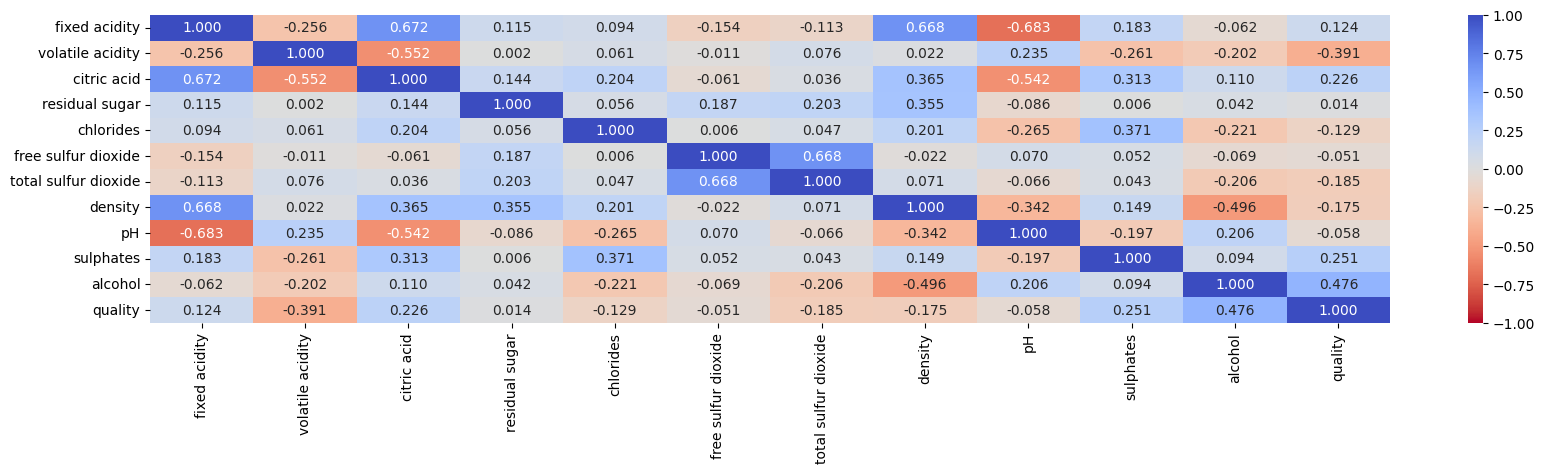

In [11]:
corr = redwine.corr()
#corr
sns.heatmap(corr, annot=True, fmt='.3f', vmin=-1, vmax=1, cmap='coolwarm_r')
plt.show()

In [12]:
mask = np.tril(np.ones_like(corr), k=0) # 대각선 포함 아래가 1인 삼각행렬(기본값0)
mask = np.tril(np.ones_like(corr), k=-1) # 대각선 제외 아래가 1인 삼각행렬
mask = np.triu(np.ones_like(corr), k=1)  # 대각선 제외 위가 1인 삼각행렬
mask = np.triu(np.ones_like(corr), k=0)  # 대각선 포함 위가 1인 삼각행렬
mask

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

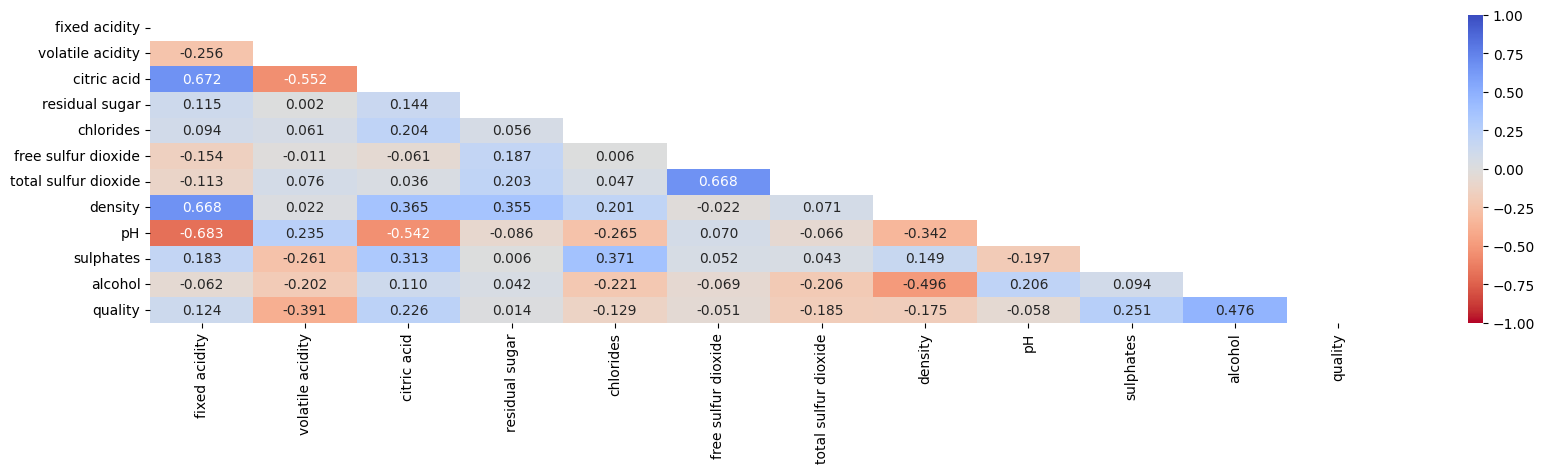

In [13]:
sns.heatmap(corr, annot=True, fmt='.3f', vmin=-1, vmax=1, cmap='coolwarm_r', mask=mask)
plt.show()

## 1.4 분류모형의 feature_importance_
- 모형의 feature_importance_ 속성은 독립변수들이 종속변수에 영향을 주는 정도를 저장
- DecisionTreeClassifier, RandomForestClassifier(tree계열), GradientBoostingClassifier, XGBclassifier, LGBMclassifier, CatBoostClassifier
- LogisticRegression이나 SVC, MLPclassifier, MultinomialNB등은 feature_importance_없음

In [14]:
X = redwine.iloc[:, :-1].to_numpy()
y = redwine.iloc[:, -1].values
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(X, y,
                                                   test_size=0.3,
                                                   stratify=y) # 층화추출
train_X.shape, train_y.shape, test_X.shape, test_y.shape, type(train_X)

((1119, 11), (1119,), (480, 11), (480,), numpy.ndarray)

In [15]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=10,
                                 random_state=10)
rf_model.fit(train_X, train_y)

RandomForestClassifier(n_estimators=10, random_state=10)

In [16]:
features = pd.DataFrame(np.c_[redwine.columns[:-1],
                            rf_model.feature_importances_],
                       columns=['feature', 'importance'])
features['importance'].sum()

1.0

In [17]:
features.sort_values(by='importance', ascending=False, inplace=True)
features

,feature,importance
10,alcohol,0.159505
9,sulphates,0.1095
6,total sulfur dioxide,0.108019
1,volatile acidity,0.090518
0,fixed acidity,0.087218
4,chlorides,0.084939
7,density,0.082711
3,residual sugar,0.075343
8,pH,0.071206
2,citric acid,0.069752


### feature_importance_를 이용한 변수 중요도 시각화

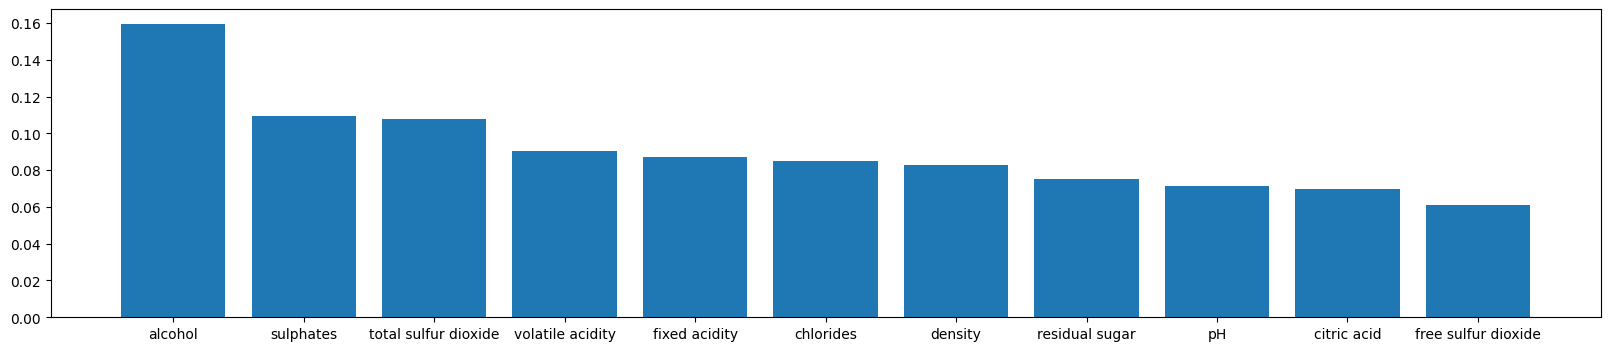

In [18]:
plt.bar(features.feature, features.importance)
plt.show()

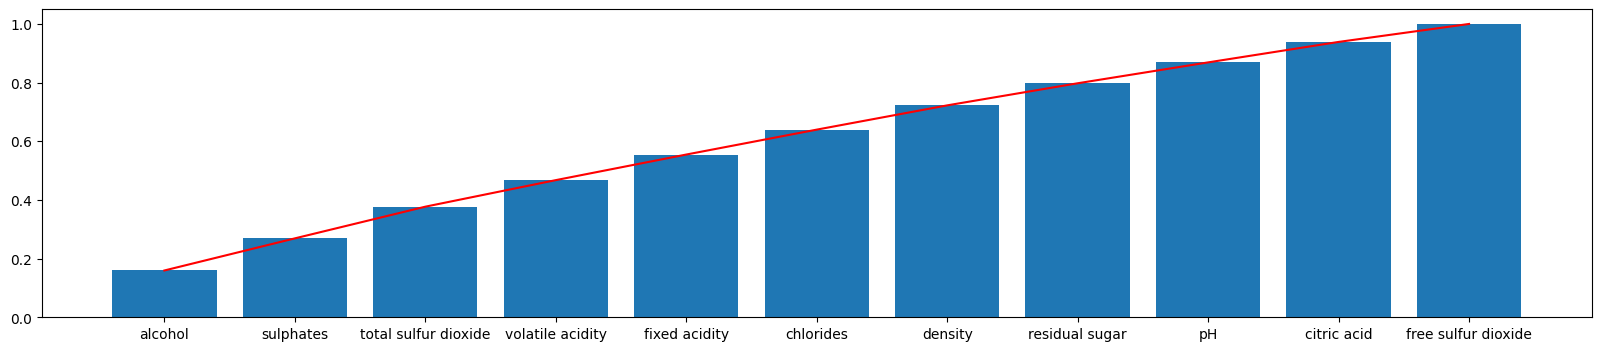

In [19]:
# 누적합을 이용한 시각화
y_stack = np.cumsum(features.importance) # importance 누적
# y_stack 
plt.bar(features.feature, y_stack)
plt.plot(features.feature, y_stack, c='r')
plt.show()

### RFE(Recursive Feature Elimination) 방식
- 중요도에 따라 낮은 변수부터 하나씩 제거해 나가면서 최종적으로 선택하고자 하는 변수의 갯수만큼 남긴다

In [20]:
# 5개의 특징이 남을 때까지 변수를 제거(기준 : feature_importance_)
from sklearn.feature_selection import RFE
rfe_model = RFE(#RandomForestClassifier(n_estimators=10,random_state=10)
    rf_model,s
    n_features_to_select=5
)
rfe_model.fit(train_X, train_y)
# rfe_model.get_support()
features_rfe = pd.DataFrame(np.c_[redwine.columns[:-1],
                                 rfe_model.get_support()],
                           columns=['feature', 'selected'])
features_rfe.sort_values(by='selected', ascending=False)

,feature,selected
1,volatile acidity,True
6,total sulfur dioxide,True
7,density,True
9,sulphates,True
10,alcohol,True
0,fixed acidity,False
2,citric acid,False
3,residual sugar,False
4,chlorides,False
5,free sulfur dioxide,False
